In [1]:
# External Imports
import sys
from pathlib import Path
import torch
import torch.optim as optim
import torch.nn as nn

# Internal Imports
sys.path.insert(0, '../src')
from src.Dataset.mri_split import split_patients
from src.Dataset.data_loaders import get_dataloaders
from src.Dataset.cache import load_cache
from src.Model.train import fit
from src.Model.Unet.Unet import UNetModel, DiceLoss
from src.Visualization.visualization import plot_loss_acc

In [2]:
accepted_data = {}
rejected_data = {}
try:
    accepted_data = load_cache(Path("../data/processed/cache/accepted_data.json"), Path.cwd().parent)
    rejected_data = load_cache(Path("../data/processed/cache/rejected_data.json"), Path.cwd().parent)
except BaseException as e:
    print(e)

[INFO]  Cache loaded from ..\data\processed\cache\accepted_data.json
[INFO]  Cache loaded from ..\data\processed\cache\rejected_data.json


In [3]:
SPLIT_SEED = 42
train_patients, val_patients, test_patients = split_patients(accepted_data, seed=SPLIT_SEED)

[INFO]  Splitting dataset with seed 42...
[INFO]  Train Set: 76  | Tumor Ratio: 0.352
[INFO]  Valid Set: 17  | Tumor Ratio: 0.360
[INFO]  Test Set:  17   | Tumor Ratio: 0.372


In [4]:
BATCH_SIZE = 32
train_dataloader, val_dataloader, test_dataloader = get_dataloaders(
    train_patients,
    val_patients,
    test_patients,
    batch_size=BATCH_SIZE,
    segmentation=True
)

C:\Users\pc\miniconda3\envs\BrainTumorMRIClassification\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [5]:
images, masks = next(iter(train_dataloader))

In [6]:
print(images.shape)
print(masks.shape)
print(masks.unique())
print(images.dtype)
print(masks.dtype)

torch.Size([32, 3, 224, 224])
torch.Size([32, 1, 224, 224])
tensor([0., 1.])
torch.float32
torch.float32


# CHECKPOINT

Next is writing the training loop

In [7]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(device)

model = UNetModel(in_channels = 3, out_channels = 1)
model = model.to(device)

loss_fn = DiceLoss()

OPTIMIZER = torch.optim.Adam(model.parameters(), lr=1e-4)
EPOCHS = 100
PATIENCE = 5
SEGMENTATION = True

cuda


In [8]:
history = fit(model, train_dataloader, val_dataloader, loss_fn, OPTIMIZER, device, EPOCHS, PATIENCE, SEGMENTATION)


Epoch   1/100 | Time: 0:00:55 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9433  Dice: 0.1667
  Valid  — Loss: 0.9497  Dice: 0.1214

Epoch   2/100 | Time: 0:00:54 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9248  Dice: 0.2878
  Valid  — Loss: 0.9339  Dice: 0.2244

Epoch   3/100 | Time: 0:00:54 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.9136  Dice: 0.3220
  Valid  — Loss: 0.9562  Dice: 0.1532

Epoch   4/100 | Time: 0:00:54 | Patience: 1/5 | LR: 0.0001
  Train  — Loss: 0.8997  Dice: 0.3509
  Valid  — Loss: 0.9180  Dice: 0.2345

Epoch   5/100 | Time: 0:00:54 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8816  Dice: 0.4048
  Valid  — Loss: 0.9019  Dice: 0.2382

Epoch   6/100 | Time: 0:00:54 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8597  Dice: 0.4475
  Valid  — Loss: 0.8880  Dice: 0.3337

Epoch   7/100 | Time: 0:00:54 | Patience: 0/5 | LR: 0.0001
  Train  — Loss: 0.8250  Dice: 0.5180
  Valid  — Loss: 0.8566  Dice: 0.3929

Epoch   8/100 | Time: 0:00:54 | Patience: 0/5 |

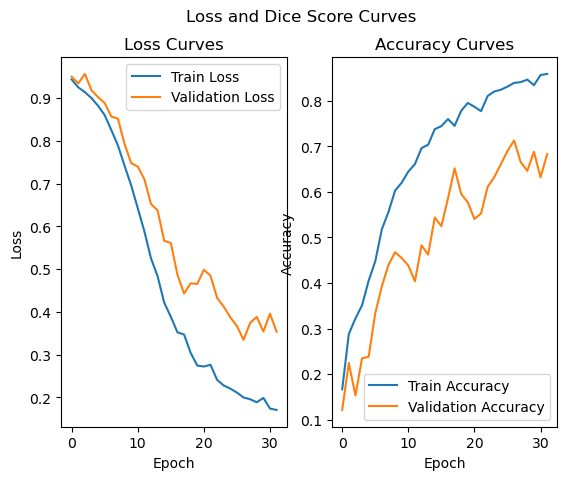

In [9]:
plot_loss_acc(history, "Loss and Dice Score Curves")